# Segmentação de óleo, água e gás por meio de IA

##### data: Outubro de 2026

## Conteúdo:

1. Import de bibliotecas e caminhos
2. Cortando imagem para se livrar de erros no dataset
3. Fazendo data augmentation e salvando em folder separado
4. Classes da máscara (cor → classe → one-hot)
5. Carregamento do dataset (pares imagem/máscara, treino/teste, `tf.data`)
6. Modelo U-Net com Attention (aceita qualquer tamanho de imagem)
7. Métricas e loss multiclasse
8. Treinamento
9. Visualização das previsões
10. Classe dataset do pytorch (necessário para compatibilidade com pytorch)
11. DCA UNet
12. Exponential Moving Average

> Rode sempre na ordem (**Restart Kernel → Run All**). Rodar células fora de ordem deixa
> versões antigas de funções/modelos na memória.

#### 1. Imports: `Checar pyprojects.toml` para ver versões e bibliotecas usadas

In [76]:
import os
import random
from glob import glob
import copy

import math

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import albumentations as A

import tensorflow as tf
import keras

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

In [2]:
# ===== Caminhos (altere só aqui) =====
BASE_DIR = r'C:\labmems\wag-segment\data\out_segmentation'

ORIGINAL_DIR  = os.path.join(BASE_DIR, 'original')
SLICED_DIR    = os.path.join(BASE_DIR, 'sliced')
AUGMENTED_DIR = os.path.join(BASE_DIR, 'augmented')

NOME_ORIGINAL = 'outubro_2026_original.png'
NOME_CORTADO  = 'out_2026.png'

PASTA_MODELOS = 'modelos'
os.makedirs(PASTA_MODELOS, exist_ok=True)

#### 2. Cortando Imagem e salvando imagem cortada

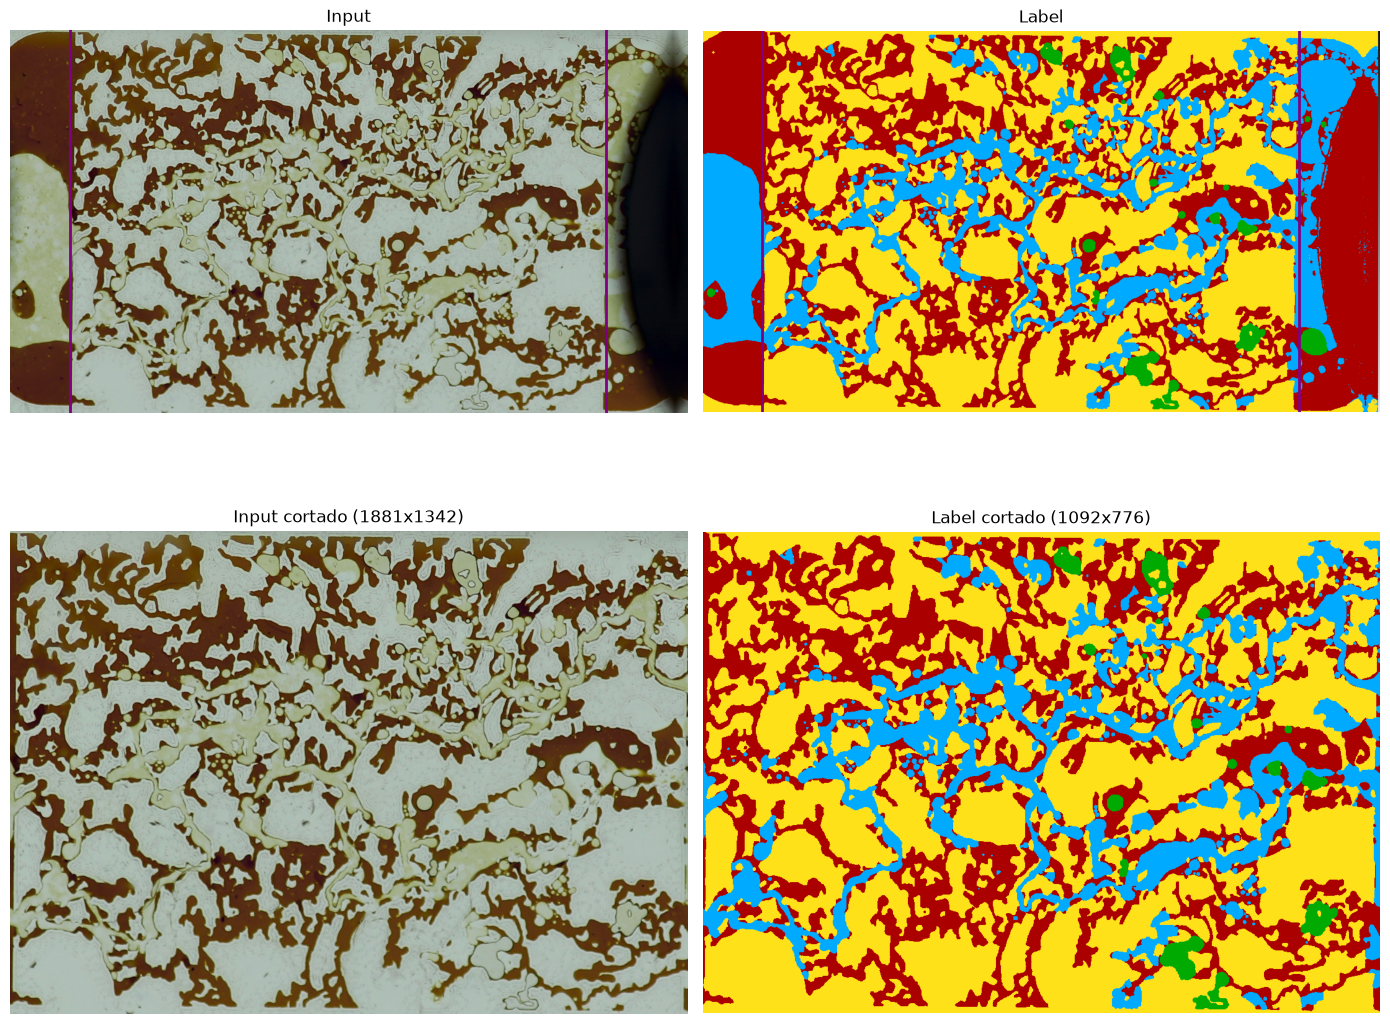

✅ Input salvo em: C:\labmems\wag-segment\data\out_segmentation\sliced\input\out_2026.png
✅ Label salvo em: C:\labmems\wag-segment\data\out_segmentation\sliced\label\out_2026.png


In [3]:
def cortar_horizontal(img, esquerda=0.0, direita=1.0):
    '''
    Corta a imagem pela esquerda e pela direita.
    esquerda: posição relativa (0 a 1) do corte esquerdo
    direita:  posição relativa (0 a 1) do corte direito
    Retorna a imagem cortada e as coordenadas em pixels (x0, x1).
    '''
    assert 0 <= esquerda < direita <= 1, "Use 0 <= esquerda < direita <= 1"
    x0 = round(esquerda * img.width)
    x1 = round(direita * img.width)
    return img.crop((x0, 0, x1, img.height)), (x0, x1)


# ===== Caminhos =====
input_img_path = os.path.join(ORIGINAL_DIR, 'input', NOME_ORIGINAL)
label_img_path = os.path.join(ORIGINAL_DIR, 'label', NOME_ORIGINAL)

input_out_path = os.path.join(SLICED_DIR, 'input', NOME_CORTADO)
label_out_path = os.path.join(SLICED_DIR, 'label', NOME_CORTADO)

# ===== Posições relativas dos cortes =====
# 0 --> borda esquerda | 1 --> borda direita
corte_esquerda = 0.088
corte_direita = 0.88

# ===== Carrega e corta =====
input_img = Image.open(input_img_path).convert("RGB")
label_img = Image.open(label_img_path).convert("RGB")

input_crop, (xi0, xi1) = cortar_horizontal(input_img, corte_esquerda, corte_direita)
label_crop, (xl0, xl1) = cortar_horizontal(label_img, corte_esquerda, corte_direita)

# ===== Visualização =====
fig, ax = plt.subplots(2, 2, figsize=(14, 12))

# Linha 1: originais com as linhas de corte
for a, img, (x0, x1), titulo in [
    (ax[0, 0], input_img, (xi0, xi1), "Input"),
    (ax[0, 1], label_img, (xl0, xl1), "Label"),
]:
    a.imshow(img)
    a.axvline(x=x0, linewidth=2, color="purple")
    a.axvline(x=x1, linewidth=2, color="purple")
    a.set_title(titulo)
    a.axis("off")

# Linha 2: resultado do corte
ax[1, 0].imshow(input_crop)
ax[1, 0].set_title(f"Input cortado ({input_crop.width}x{input_crop.height})")
ax[1, 0].axis("off")

ax[1, 1].imshow(label_crop)
ax[1, 1].set_title(f"Label cortado ({label_crop.width}x{label_crop.height})")
ax[1, 1].axis("off")

plt.tight_layout()
plt.show()

# ===== Salva os cortes =====
os.makedirs(os.path.dirname(input_out_path), exist_ok=True)
os.makedirs(os.path.dirname(label_out_path), exist_ok=True)

input_crop.save(input_out_path)
label_crop.save(label_out_path)

print(f"✅ Input salvo em: {input_out_path}")
print(f"✅ Label salvo em: {label_out_path}")

#### 3. Fazendo Data Augmentation

Fazendo transformações lineares e elásticas na imagem para gerar novos dados.

- A **máscara** é passada como `mask` para o albumentations: assim ela recebe as mesmas
  transformações espaciais, mas com interpolação *nearest* (não cria cores misturadas nas
  bordas entre as classes).
- A seed vai no `A.Compose(seed=...)`: no albumentations 2.x, `random.seed`/`np.random.seed`
  não controlam as transformações.

In [4]:
# HYPERPARAMETROS DO AUGMENTATION

NUM_IMAGENS = 50   # num de imagens aumentadas
HEIGHT = 770       # altura final das imagens aumentadas
WIDTH = 1400       # largura final das imagens aumentadas
SEED = 42

In [5]:
def create_augmentation(height, width, seed=None):
    '''
    Cria pipeline de data augmentation.

    Input e máscara recebem as mesmas transformações espaciais.
    Transformações de cor não são aplicadas para não mudar a natureza das imagens.

    Ajuste os valores nessa função para controlar a distorção, favor checar documentação do albumentations:
    https://github.com/albumentations-team/albumentations
    '''
    return A.Compose(
        [
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),

            # Substitui o ShiftScaleRotate (depreciado) com os mesmos limites:
            # deslocamento de até 50%, zoom de 1x a 2.5x, rotação de até 180°
            A.Affine(
                translate_percent=(-0.5, 0.5),
                scale=(1.0, 2.5),
                rotate=(-180, 180),
                border_mode=cv2.BORDER_REFLECT,
                p=1.0,
            ),

            # border_mode=REFLECT: o padrão (CONSTANT) preenche as bordas com preto,
            # e esse preto na máscara viraria uma classe errada
            A.GridDistortion(num_steps=4, distort_limit=0.2,
                             border_mode=cv2.BORDER_REFLECT, p=0.7),

            # Já entrega no tamanho final (height, width); o Resize extra não é necessário
            A.RandomResizedCrop(
                size=(height, width),
                scale=(0.8, 1.0),
                ratio=(0.75, 1.33),
                interpolation=cv2.INTER_LINEAR,  # para a imagem; a máscara usa nearest
                p=1.0,
            ),
        ],
        seed=seed,
    )


def generate_augmented_images(input_img, label_img, input_save_dir, label_save_dir,
                              height, width, num_images, seed=None):
    '''
    Gera e salva múltiplos pares (imagem, máscara) aumentados, com o mesmo nome de arquivo.
    '''
    os.makedirs(input_save_dir, exist_ok=True)
    os.makedirs(label_save_dir, exist_ok=True)

    # Resize inicial: imagem com interpolação suave, máscara com nearest (preserva as cores)
    input_np = np.array(input_img.convert("RGB").resize((width, height), Image.Resampling.BILINEAR))
    label_np = np.array(label_img.convert("RGB").resize((width, height), Image.Resampling.NEAREST))

    # Pipeline criado UMA vez: a seed fixa torna a sequência de augmentations reprodutível
    transform = create_augmentation(height, width, seed=seed)

    for i in range(num_images):
        augmented = transform(image=input_np, mask=label_np)

        filename = f"aug_{i:04d}.png"
        Image.fromarray(augmented["image"]).save(os.path.join(input_save_dir, filename))
        Image.fromarray(augmented["mask"]).save(os.path.join(label_save_dir, filename))

    print(f"✅ {num_images} pares de imagens gerados em {os.path.dirname(input_save_dir)}")

In [6]:
input_save_dir = os.path.join(AUGMENTED_DIR, 'input')
label_save_dir = os.path.join(AUGMENTED_DIR, 'label')

generate_augmented_images(
    input_img=input_crop,
    label_img=label_crop,
    input_save_dir=input_save_dir,
    label_save_dir=label_save_dir,
    height=HEIGHT,
    width=WIDTH,
    num_images=NUM_IMAGENS,
    seed=SEED,
)

✅ 50 pares de imagens gerados em C:\labmems\wag-segment\data\out_segmentation\augmented


#### 4. Codificando classes na máscara de acordo com a cor

Classes e escala RGB:

- Água: Azul (0, 170, 255)
- Óleo: Vermelho (170, 0, 0)
- Gás: Verde (0, 170, 0)
- MiMo: Amarelo (255, 255, 25)

Vamos mapear para números inteiros:

- MiMo: Classe 0
- Água: Classe 1
- Óleo: Classe 2
- Gás: Classe 3

Cada pixel da máscara vai para a classe da **cor mais próxima** (distância euclidiana em RGB),
o que absorve pequenas variações de cor. Para o treino, a classe vira **one-hot** com 4 canais.

In [7]:
COR_PARA_CLASSE = {
    (255, 255, 25): 0,  # MiMo: amarelo
    (0, 170, 255): 1,   # Água: azul
    (170, 0, 0): 2,     # Óleo: vermelho
    (0, 170, 0): 3,     # Gás: verde
}
NOMES_CLASSES = ["MiMo", "Água", "Óleo", "Gás"]
NUM_CLASSES = len(COR_PARA_CLASSE)

_CORES = np.array(list(COR_PARA_CLASSE.keys()), dtype=np.float32)    # [C, 3]
_IDS = np.array(list(COR_PARA_CLASSE.values()), dtype=np.int64)      # [C]

# Paleta indexada pelo id da classe (para colorir previsões)
PALETA = np.zeros((NUM_CLASSES, 3), dtype=np.uint8)
for cor, idx in COR_PARA_CLASSE.items():
    PALETA[idx] = cor


def mascara_rgb_para_classes(mask_rgb):
    '''
    Converte uma máscara RGB [H, W, 3] em ids de classe [H, W] (int64),
    atribuindo cada pixel à cor de classe mais próxima.
    '''
    pixels = mask_rgb.astype(np.float32)[..., None, :]         # [H, W, 1, 3]
    distancias = np.sum((pixels - _CORES) ** 2, axis=-1)        # [H, W, C]
    return _IDS[np.argmin(distancias, axis=-1)]                 # [H, W]


def classes_para_rgb(classes):
    '''Converte ids de classe [H, W] de volta para uma imagem RGB colorida.'''
    return PALETA[classes]

aug_0000.png | imagem (770, 1400, 3) | máscara (770, 1400, 3)
  Classe 0 (MiMo): 43.9% dos pixels
  Classe 1 (Água): 20.9% dos pixels
  Classe 2 (Óleo): 32.9% dos pixels
  Classe 3 (Gás): 2.3% dos pixels


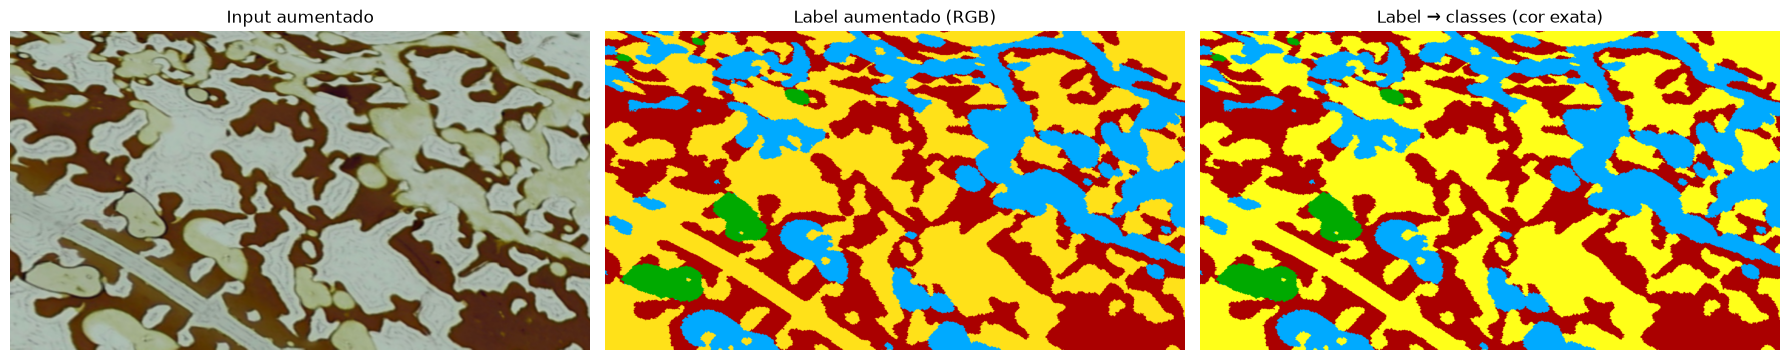

In [8]:
# Conferência: um par aumentado, a máscara convertida em classes e a proporção de cada classe
exemplo = sorted(glob(os.path.join(input_save_dir, "*.png")))[0]
nome = os.path.basename(exemplo)

img_ex = np.array(Image.open(exemplo).convert("RGB"))
mask_ex = np.array(Image.open(os.path.join(label_save_dir, nome)).convert("RGB"))
classes_ex = mascara_rgb_para_classes(mask_ex)

print(f"{nome} | imagem {img_ex.shape} | máscara {mask_ex.shape}")
# Pixels muito longe de qualquer cor de classe indicam problema no label (ex.: bordas pretas)
dist_min = np.sqrt(np.min(np.sum((mask_ex.astype(np.float32)[..., None, :] - _CORES) ** 2, axis=-1), axis=-1))
fora = (dist_min > 40).mean()
if fora > 0:
    print(f"⚠️ {100 * fora:.2f}% dos pixels da máscara não têm cor parecida com nenhuma classe")

ids, contagem = np.unique(classes_ex, return_counts=True)
for i, c in zip(ids, contagem):
    print(f"  Classe {i} ({NOMES_CLASSES[i]}): {100 * c / classes_ex.size:.1f}% dos pixels")

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].imshow(img_ex); ax[0].set_title("Input aumentado")
ax[1].imshow(mask_ex); ax[1].set_title("Label aumentado (RGB)")
ax[2].imshow(classes_para_rgb(classes_ex)); ax[2].set_title("Label → classes (cor exata)")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

#### 5. Carregamento do dataset

Imagens e máscaras são pareadas **pelo nome do arquivo** (`input/aug_0000.png` ↔ `label/aug_0000.png`).

> ⚠️ Todas as imagens aumentadas vêm de **uma única imagem original**. As imagens de teste
> são variações da mesma cena do treino, então as métricas de validação tendem a ser otimistas.
> Para uma avaliação confiável, use como teste uma imagem original que não passe pelo augmentation de treino.

In [9]:
def listar_pngs(pasta):
    '''Lista os .png de uma pasta (sem duplicar no Windows), indexados pelo nome.'''
    arquivos = glob(os.path.join(pasta, "*"))
    return {
        os.path.splitext(os.path.basename(a))[0]: a
        for a in arquivos
        if a.lower().endswith(".png")
    }


def carregar_dataset(caminho, pasta_imagens="input", pasta_mascaras="label",
                     proporcao_treino=0.8, seed=42):
    '''
    Carrega os caminhos de imagens e máscaras, pareando pelo nome do arquivo,
    e divide em treino e teste.

    Returns
    -------
    (X_train, y_train), (X_test, y_test) : listas de caminhos
    '''
    imagens = listar_pngs(os.path.join(caminho, pasta_imagens))
    mascaras = listar_pngs(os.path.join(caminho, pasta_mascaras))

    if not imagens or not mascaras:
        raise ValueError(
            f"Nenhuma imagem ou máscara encontrada em:\n"
            f"  {os.path.join(caminho, pasta_imagens)}\n"
            f"  {os.path.join(caminho, pasta_mascaras)}"
        )

    # Pareia imagem <-> máscara pelo nome do arquivo
    nomes = sorted(imagens.keys() & mascaras.keys())
    sem_mascara = imagens.keys() - mascaras.keys()
    sem_imagem = mascaras.keys() - imagens.keys()
    if sem_mascara:
        print(f"⚠️ {len(sem_mascara)} imagens sem máscara (ignoradas): {sorted(sem_mascara)[:5]}")
    if sem_imagem:
        print(f"⚠️ {len(sem_imagem)} máscaras sem imagem (ignoradas): {sorted(sem_imagem)[:5]}")
    if not nomes:
        raise ValueError("Nenhum par imagem/máscara com o mesmo nome foi encontrado!")

    # Embaralha com seed fixa (resultado reproduzível)
    random.Random(seed).shuffle(nomes)

    total = len(nomes)
    if total == 1:
        print("⚠️ Apenas 1 par encontrado: usando o mesmo para treino e teste.")
        treino, teste = nomes, nomes
    else:
        # Garante pelo menos 1 amostra em cada conjunto
        split_idx = min(max(int(total * proporcao_treino), 1), total - 1)
        treino, teste = nomes[:split_idx], nomes[split_idx:]

    X_train = [imagens[n] for n in treino]
    y_train = [mascaras[n] for n in treino]
    X_test = [imagens[n] for n in teste]
    y_test = [mascaras[n] for n in teste]

    print(f"✅ {total} pares | Treino: {len(X_train)} | Teste: {len(X_test)}")
    return (X_train, y_train), (X_test, y_test)


def mostrar_pares(titulo, X, y, n=5):
    '''Mostra os primeiros n pares imagem/máscara de um conjunto.'''
    print(f"\n{titulo} ({len(X)} pares):")
    for img, mask in list(zip(X, y))[:n]:
        print(f"  {os.path.basename(img):<30} <-> {os.path.basename(mask)}")
    if len(X) > n:
        print(f"  ... e mais {len(X) - n}")

In [10]:
(X_train, y_train), (X_test, y_test) = carregar_dataset(AUGMENTED_DIR)

mostrar_pares("Treinamento", X_train, y_train)
mostrar_pares("Teste", X_test, y_test)

✅ 50 pares | Treino: 40 | Teste: 10

Treinamento (40 pares):
  aug_0025.png                   <-> aug_0025.png
  aug_0023.png                   <-> aug_0023.png
  aug_0019.png                   <-> aug_0019.png
  aug_0011.png                   <-> aug_0011.png
  aug_0004.png                   <-> aug_0004.png
  ... e mais 35

Teste (10 pares):
  aug_0005.png                   <-> aug_0005.png
  aug_0034.png                   <-> aug_0034.png
  aug_0006.png                   <-> aug_0006.png
  aug_0008.png                   <-> aug_0008.png
  aug_0014.png                   <-> aug_0014.png
  ... e mais 5


In [ ]:
def _ler_rgb(caminho):
    '''Lê uma imagem em RGB uint8. Aceita str ou bytes e caminhos com acento (Windows).'''
    if isinstance(caminho, bytes):
        caminho = caminho.decode("utf-8")
    img = cv2.imdecode(np.fromfile(caminho, dtype=np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Não foi possível ler: {caminho}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def ler_img_dataset(caminho, tamanho=None):
    '''
    Lê uma imagem e normaliza para [0, 1].

    tamanho : (largura, altura), opcional -> redimensiona com INTER_AREA
    Returns : np.ndarray (H, W, 3) float32
    '''
    img = _ler_rgb(caminho)
    if tamanho is not None and (img.shape[1], img.shape[0]) != tuple(tamanho):
        img = cv2.resize(img, tamanho, interpolation=cv2.INTER_AREA)
    return (img / 255.0).astype(np.float32)


def ler_mask_dataset(caminho, tamanho=None):
    '''
    Lê uma máscara RGB e converte para one-hot com NUM_CLASSES canais.

    tamanho : (largura, altura), opcional -> redimensiona com INTER_NEAREST (preserva as classes)
    Returns : np.ndarray (H, W, NUM_CLASSES) float32
    '''
    mask = _ler_rgb(caminho)
    if tamanho is not None and (mask.shape[1], mask.shape[0]) != tuple(tamanho):
        mask = cv2.resize(mask, tamanho, interpolation=cv2.INTER_NEAREST)
    classes = mascara_rgb_para_classes(mask)
    return np.eye(NUM_CLASSES, dtype=np.float32)[classes]

In [ ]:
# Tamanho (largura, altura) das imagens que entram no modelo.
# = tamanho das imagens aumentadas -> nenhuma imagem é redimensionada.
# O modelo aceita qualquer tamanho; o TAMANHO só garante que todas as imagens do batch sejam iguais.
TAMANHO = (WIDTH, HEIGHT)

# Imagens grandes (770x1400) ocupam muita memória no treino.
# Comece com 1; suba para 2 só se couber. Se faltar memória mesmo com 1,
# reduza o TAMANHO, ex.: (WIDTH // 2, HEIGHT // 2).
BATCH_SIZE = 1


def tf_parse(x, y):
    '''Lê imagem e máscara a partir dos caminhos, dentro do pipeline do tf.data.'''
    def _parse(x, y):
        return ler_img_dataset(x, tamanho=TAMANHO), ler_mask_dataset(y, tamanho=TAMANHO)

    img, mask = tf.numpy_function(_parse, [x, y], [tf.float32, tf.float32])

    # numpy_function perde a informação de shape; é preciso redefinir
    img.set_shape([TAMANHO[1], TAMANHO[0], 3])
    mask.set_shape([TAMANHO[1], TAMANHO[0], NUM_CLASSES])
    return img, mask


def tf_dataset(X, y, batch_size=1, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X), seed=42, reshuffle_each_iteration=True)
    dataset = dataset.map(tf_parse, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


dataset_train = tf_dataset(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
dataset_test = tf_dataset(X_test, y_test, batch_size=BATCH_SIZE)

# Conferência rápida
for img_batch, mask_batch in dataset_train.take(1):
    print("Imagens:", img_batch.shape, img_batch.dtype)
    print("Máscaras:", mask_batch.shape, mask_batch.dtype)
    print("Soma one-hot por pixel = 1:", bool(tf.reduce_all(tf.reduce_sum(mask_batch, axis=-1) == 1)))

#### 6. Modelo U-Net com Attention

O modelo aceita imagens de **qualquer altura e largura**: o padding até múltiplos de 16
é feito dentro dele e desfeito na saída. A saída tem `NUM_CLASSES` canais com `softmax`.

In [ ]:
from keras import ops
from keras.saving import register_keras_serializable
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, UpSampling2D, Conv2DTranspose, BatchNormalization,
                                     Dropout, Activation, MaxPool2D, Concatenate, Multiply, Add, Layer)

MULTIPLO = 16  # 4 níveis de MaxPool -> altura e largura precisam ser múltiplas de 2**4


@register_keras_serializable(package="wag")
class PadMultiplo(Layer):
    '''Completa altura e largura com zeros (embaixo/à direita) até virarem múltiplos de `multiplo`.'''
    def __init__(self, multiplo=MULTIPLO, **kwargs):
        super().__init__(**kwargs)
        self.multiplo = multiplo

    def call(self, x):
        h, w = ops.shape(x)[1], ops.shape(x)[2]
        pad_h = (self.multiplo - h % self.multiplo) % self.multiplo
        pad_w = (self.multiplo - w % self.multiplo) % self.multiplo
        return ops.pad(x, [[0, 0], [0, pad_h], [0, pad_w], [0, 0]])

    def compute_output_shape(self, input_shape):
        def ajusta(d):
            return None if d is None else d + (self.multiplo - d % self.multiplo) % self.multiplo
        return (input_shape[0], ajusta(input_shape[1]), ajusta(input_shape[2]), input_shape[3])

    def get_config(self):
        return {**super().get_config(), "multiplo": self.multiplo}


@register_keras_serializable(package="wag")
class CortaComoReferencia(Layer):
    '''Corta x para a mesma altura e largura de `referencia` (desfaz o PadMultiplo).'''
    def call(self, x, referencia):
        h, w = ops.shape(referencia)[1], ops.shape(referencia)[2]
        return x[:, :h, :w, :]

    def compute_output_shape(self, x_shape, referencia_shape):
        return (x_shape[0], referencia_shape[1], referencia_shape[2], x_shape[3])


def bloco_conv(input, num_filters, dropout_rate=0.2):
    x = Conv2D(num_filters, 3, padding="same")(input)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(num_filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    if dropout_rate > 0:
        x = Dropout(dropout_rate)(x)

    return x


def bloco_encoder(input, num_filters):
    x = bloco_conv(input, num_filters)
    p = MaxPool2D((2, 2))(x)
    return x, p


def bloco_decoder(input, skip_features, num_filters):
    x = Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(input)
    x = Concatenate()([x, skip_features])
    x = bloco_conv(x, num_filters)
    return x


def attention_block(x, g, inter_channel):
    '''
    Attention block da U-Net.

    x: saída da skip connection (resolução N)
    g: saída do nível de baixo (resolução N/2)
    '''
    # g está sempre um nível abaixo de x (metade da resolução): upsampling fixo de 2x
    g = Conv2D(inter_channel, (1, 1), padding='same')(g)
    g = UpSampling2D(size=(2, 2))(g)

    theta_x = Conv2D(inter_channel, (1, 1), padding='same')(x)
    add_xg = Add()([theta_x, g])
    act_xg = Activation('relu')(add_xg)
    psi = Conv2D(1, (1, 1), padding='same')(act_xg)
    psi = Activation('sigmoid')(psi)
    return Multiply()([x, psi])


def modelo_unet_attention(input_shape=(None, None, 3), num_classes=1):
    '''
    U-Net com attention blocks que aceita imagens de QUALQUER altura e largura.

    Args:
        input_shape: (altura, largura, canais). None = tamanho livre.
        num_classes: 1 -> saída binária (sigmoid); >1 -> uma saída por classe (softmax).
    '''
    inputs = Input(input_shape)
    padded_inputs = PadMultiplo(MULTIPLO)(inputs)

    # Encoder
    s1, p1 = bloco_encoder(padded_inputs, 64)
    s2, p2 = bloco_encoder(p1, 64 * 2)  # 128
    s3, p3 = bloco_encoder(p2, 64 * 4)  # 256
    s4, p4 = bloco_encoder(p3, 64 * 8)  # 512

    # Bottleneck
    b1 = bloco_conv(p4, 64 * 16)  # 1024

    # Decoder with attention
    d1 = bloco_decoder(b1, attention_block(s4, b1, 64 * 8), 64 * 8)  # 512
    d2 = bloco_decoder(d1, attention_block(s3, d1, 64 * 4), 64 * 4)  # 256
    d3 = bloco_decoder(d2, attention_block(s2, d2, 64 * 2), 64 * 2)  # 128
    d4 = bloco_decoder(d3, attention_block(s1, d3, 64), 64)          # 64

    # Remove o padding: volta para o tamanho original da entrada
    cropped_outputs = CortaComoReferencia()(d4, inputs)

    ativacao = "sigmoid" if num_classes == 1 else "softmax"
    outputs = Conv2D(num_classes, 1, padding="same", activation=ativacao)(cropped_outputs)

    return Model(inputs, outputs, name="UNet_Attention")

#### 7. Métricas e loss multiclasse

As funções foram baseadas no código disponibilizado no repositório oficial do keras.

IoU e Dice Coefficient https://towardsdatascience.com/metrics-to-evaluate-your-semantic-segmentation-model-6bcb99639aa2

Dice Loss - https://medium.com/ai-salon/understanding-dice-loss-for-crisp-boundary-detection-bb30c2e5f62b

Dice e IoU são calculados **por classe** e depois tirada a média (*macro*), assim as classes
pequenas pesam tanto quanto as grandes. A loss combina *categorical crossentropy* (estável no
começo do treino) com *dice loss* (ajuda com o desbalanceamento entre as classes).

In [ ]:
@register_keras_serializable(package="wag")
def dice_coef(y_true, y_pred, smooth=1.0):
    '''Dice médio entre as classes. y_true e y_pred: [B, H, W, C].'''
    y_true = tf.cast(y_true, y_pred.dtype)
    intersecao = tf.reduce_sum(y_true * y_pred, axis=[1, 2])                  # [B, C]
    soma = tf.reduce_sum(y_true, axis=[1, 2]) + tf.reduce_sum(y_pred, axis=[1, 2])
    return tf.reduce_mean((2.0 * intersecao + smooth) / (soma + smooth))


@register_keras_serializable(package="wag")
def iou(y_true, y_pred, smooth=1.0):
    '''IoU (Jaccard) médio entre as classes. y_true e y_pred: [B, H, W, C].'''
    y_true = tf.cast(y_true, y_pred.dtype)
    intersecao = tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    uniao = tf.reduce_sum(y_true, axis=[1, 2]) + tf.reduce_sum(y_pred, axis=[1, 2]) - intersecao
    return tf.reduce_mean((intersecao + smooth) / (uniao + smooth))


@register_keras_serializable(package="wag")
def dice_coef_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


@register_keras_serializable(package="wag")
def cce_dice_loss(y_true, y_pred):
    '''Categorical crossentropy + dice loss.'''
    y_true = tf.cast(y_true, y_pred.dtype)
    cce = tf.reduce_mean(keras.losses.categorical_crossentropy(y_true, y_pred))
    return cce + dice_coef_loss(y_true, y_pred)

#### 8. Treinamento

In [ ]:
from tensorflow.keras.optimizers import Adam

EPOCHS = 50
LR = 1e-4

keras.backend.clear_session()   # libera modelos antigos da memória ao rodar de novo

model = modelo_unet_attention(num_classes=NUM_CLASSES)
model.compile(
    optimizer=Adam(LR),
    loss=cce_dice_loss,
    metrics=[dice_coef, iou, keras.metrics.CategoricalAccuracy(name="accuracy")],
)
model.summary()

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

caminho_melhor_modelo = os.path.join(PASTA_MODELOS, 'unet_attention_best.keras')

callbacks = [
    # salva só o melhor modelo, pelo IoU da VALIDAÇÃO
    ModelCheckpoint(caminho_melhor_modelo, monitor='val_iou', mode='max',
                    save_best_only=True, verbose=1),
    # reduz o learning rate quando a validação para de melhorar
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    # para o treino se o IoU de validação não melhorar e volta para os melhores pesos
    EarlyStopping(monitor='val_iou', mode='max', patience=15,
                  restore_best_weights=True, verbose=1),
    # histórico em CSV
    CSVLogger(os.path.join(PASTA_MODELOS, 'historico.csv')),
]

In [ ]:
history = model.fit(
    dataset_train,
    epochs=EPOCHS,
    validation_data=dataset_test,
    callbacks=callbacks,
    shuffle=False,   # o embaralhamento já é feito no tf_dataset (evita o aviso do Keras)
)

In [ ]:
# Curvas de treino
h = history.history
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
for a, chave, titulo in [(ax[0], 'loss', 'Loss'), (ax[1], 'dice_coef', 'Dice'), (ax[2], 'iou', 'IoU')]:
    a.plot(h[chave], label='treino')
    a.plot(h['val_' + chave], label='validação')
    a.set_title(titulo); a.set_xlabel('Época'); a.legend()
plt.tight_layout()
plt.show()

#### 9. Visualização das previsões

Carrega o melhor modelo salvo e compara a máscara real com a prevista no conjunto de teste.

In [ ]:
melhor_modelo = keras.models.load_model(caminho_melhor_modelo)

N_EXEMPLOS = 3
for x_path, y_path in list(zip(X_test, y_test))[:N_EXEMPLOS]:
    img = ler_img_dataset(x_path, tamanho=TAMANHO)
    real = np.argmax(ler_mask_dataset(y_path, tamanho=TAMANHO), axis=-1)
    prevista = np.argmax(melhor_modelo.predict(img[None], verbose=0)[0], axis=-1)

    # IoU por classe (máscara "dura", depois do argmax)
    ious = []
    for c in range(NUM_CLASSES):
        inter = np.logical_and(real == c, prevista == c).sum()
        uniao = np.logical_or(real == c, prevista == c).sum()
        ious.append(f"{NOMES_CLASSES[c]}: {inter / uniao:.2f}" if uniao else f"{NOMES_CLASSES[c]}: -")

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    ax[0].imshow(img); ax[0].set_title(os.path.basename(x_path))
    ax[1].imshow(classes_para_rgb(real)); ax[1].set_title("Máscara real")
    ax[2].imshow(classes_para_rgb(prevista)); ax[2].set_title("Máscara prevista")
    for a in ax:
        a.axis("off")
    fig.suptitle("IoU por classe — " + " | ".join(ious))
    plt.tight_layout()
    plt.show()

#### 10. Classe de dataset do pytorch

In [58]:
class WagDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, label_dir, train, train_percent=0.8, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir

        self.train_percent = train_percent


        # split de treino e validação
        if train:
            self.imgs_names = os.listdir(img_dir)[:int(len(os.listdir(img_dir)) * self.train_percent)]
            self.masks_names = os.listdir(label_dir)[:int(len(os.listdir(label_dir)) * self.train_percent)]
        else:
            self.imgs_names = os.listdir(img_dir)[int(len(os.listdir(img_dir)) * self.train_percent):]
            self.masks_names = os.listdir(label_dir)[int(len(os.listdir(label_dir)) * self.train_percent):]

        self.color_map = COR_PARA_CLASSE

        # transformador de imagem para tensor
        if transform == None:
            self.transform = transforms.ToTensor()
        else:
            self.transform = transform

    def _mask_to_classes(self, mask: np.ndarray):
        """
        Converte a representação RGB da máscara para uma classe numérica
        a ser usada na classe `nn.CrossEntropyLoss()` para fazer gradiente
        descendente no modelo.

        Parametros
        ----------
        mask : np.ndarray
            Shape [H, W, 3], tipicamente em dtype uint8.

        Retorna
        -------
        np.ndarray
            Shape [H, W], dtype int64, containing class IDs.
        """

        # [C, 3]
        colors = np.array(
            list(self.color_map.keys()),
            dtype=np.float32
        )

        # [C]
        class_ids = np.array(
            list(self.color_map.values()),
            dtype=np.int64
        )

        # [H, W, 3] -> [H, W, 1, 3]
        pixels = mask.astype(np.float32)[..., None, :]

        # Broadcasting:
        #
        # pixels: [H, W, 1, 3]
        # colors:          [C, 3]
        #
        # result: [H, W, C]
        distances_sq = np.sum(
            (pixels - colors) ** 2,
            axis=-1
        )

        # For every pixel, find nearest color.
        # [H, W, C] -> [H, W]
        nearest = np.argmin(distances_sq, axis=-1)

        # Convert color index -> actual class ID
        target = class_ids[nearest]

        return target

    def class_to_mask(self, probs: torch.Tensor) -> np.ndarray:
        """
        Converte probabilidades previstas pelo modelo em máscaras RGB.

        Parametros
        ----------
        probs : torch.Tensor
            Shape [B, C, H, W], em float32.

        Retorna
        -------
        np.ndarray
            Shape [B, H, W, 3], dtype int64, contendo as cores
            originais de cada classe de acordo com self.color_map.
        """

        # [B, C, H, W] -> [B, H, W]
        # Seleciona a classe mais provável para cada pixel.
        classes = probs.argmax(dim=1).cpu().numpy()

        # Inverte o mapeamento RGB -> classe para classe -> RGB.
        # [C, 3]
        colors = np.empty((probs.shape[1], 3), dtype=np.int64)

        for rgb, class_id in self.color_map.items():
            colors[class_id] = rgb

        # [B, H, W] -> [B, H, W, 3]
        mask = colors[classes]

        return mask
        

    def __len__(self):
        assert len(self.imgs_names) == len(self.masks_names)
        return len(self.imgs_names)

    def __getitem__(self, idx):

        img = Image.open(os.path.join(self.img_dir, self.imgs_names[idx]))
        mask = Image.open(os.path.join(self.label_dir, self.masks_names[idx]))

        # converter imagem para tensor
        img = self.transform(img)

        # converter mascara para tensor
        mask = np.asarray(mask)
        mask = self._mask_to_classes(mask)
        mask = torch.from_numpy(mask).long()

        return img, mask
        

In [65]:
train_dataset = WagDataset(input_save_dir, label_save_dir, train=True)
val_dataset = WagDataset(input_save_dir, label_save_dir, train=False)

print(f"Verificando instancia do dataset.")
print("-----------------------------------")
print(f"Tamanho do treino: {len(train_dataset)} amostras.")
print(f"Tamanho do treino: {len(val_dataset)} amostras.")

img, mask = train_dataset[0]
print(f"Shape da imagem: {img.shape}")
print(f"Shape da máscara: {mask.shape}")

print("-----------------------------------")
print(f"Amostra de imagem e máscara numericamente")
print(img)
print(mask)
print("-----------------------------------")

Verificando instancia do dataset.
-----------------------------------
Tamanho do treino: 40 amostras.
Tamanho do treino: 10 amostras.
Shape da imagem: torch.Size([3, 770, 1400])
Shape da máscara: torch.Size([770, 1400])
-----------------------------------
Amostra de imagem e máscara numericamente
tensor([[[0.5922, 0.6078, 0.6196,  ..., 0.6706, 0.6706, 0.6706],
         [0.5725, 0.5882, 0.6039,  ..., 0.6667, 0.6667, 0.6706],
         [0.5451, 0.5608, 0.5804,  ..., 0.6706, 0.6706, 0.6706],
         ...,
         [0.6588, 0.6588, 0.6588,  ..., 0.3294, 0.3294, 0.3294],
         [0.6588, 0.6588, 0.6588,  ..., 0.3294, 0.3294, 0.3294],
         [0.6431, 0.6431, 0.6431,  ..., 0.3255, 0.3255, 0.3294]],

        [[0.6431, 0.6588, 0.6706,  ..., 0.7294, 0.7294, 0.7294],
         [0.6196, 0.6353, 0.6510,  ..., 0.7255, 0.7255, 0.7294],
         [0.5961, 0.6118, 0.6314,  ..., 0.7294, 0.7294, 0.7294],
         ...,
         [0.6941, 0.6980, 0.6980,  ..., 0.1569, 0.1569, 0.1569],
         [0.6941, 0.69

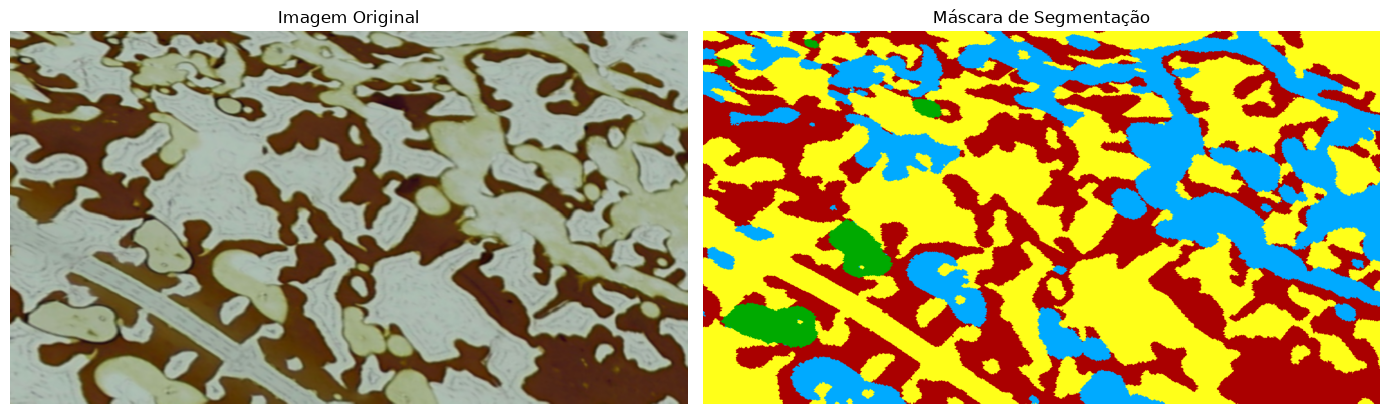

In [66]:
# visualização do mapeamento de classes

# [C, H, W] -> [H, W, C]
img_rgb = img.permute(1, 2, 0).cpu().numpy()

# [H, W] -> [H, W, C] -> [1, C, H, W]
num_classes = len(train_dataset.color_map)

# simulando output de rede neural}
mask_probs = F.one_hot(
    mask.long(),
    num_classes=num_classes
).permute(2, 0, 1).unsqueeze(0).float()

# [1, C, H, W] -> [1, H, W, 3] -> [H, W, 3]
mask_rgb = train_dataset.class_to_mask(mask_probs)[0]

# Plotar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("Imagem Original")
axes[0].axis("off")

axes[1].imshow(mask_rgb.astype("uint8"))
axes[1].set_title("Máscara de Segmentação")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### 11. DCA UNet

Variante da UNet com Double Convolutions, mecanismos de Atenção e RoPE (Rotary Positional Embedding)

In [69]:
# pegar device (cpu ou cuda)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [70]:
class RoPE(nn.Module):
    def __init__(self, sequence_len, embedding_dim):
        super(RoPE, self).__init__()

        self.sequence_len = sequence_len
        self.embedding_dim = embedding_dim

        pos_vec = torch.arange(0, sequence_len, 1, dtype=torch.float32)
        dims_vec = torch.arange(0, embedding_dim//2, 1, dtype=torch.float32)

        unity = torch.ones([sequence_len, embedding_dim//2])
        pos = pos_vec.reshape(sequence_len, 1) * unity
        dims = dims_vec.reshape(1, embedding_dim//2) * unity

        theta = pos / 10000**(2 * dims / embedding_dim)
        self.register_buffer("sin", torch.sin(theta))
        self.register_buffer("cos", torch.cos(theta))

    def forward(self, x):
        batch_size= x.size()[0]
        pairs = x.reshape(batch_size, self.sequence_len, self.embedding_dim//2, 2)
        out1 = self.cos * pairs[:, :, :, 0] - self.sin * pairs[:, :, :, 1]
        out2 = self.sin * pairs[:, :, :, 0] + self.cos * pairs[:, :, :, 1]
        out = torch.stack((out1, out2), dim=-1)
        return out.reshape(batch_size, self.sequence_len, self.embedding_dim)


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_prob=0.20):
        super(DoubleConv, self).__init__()

        # define double convolution operation with dropout
        self.operation = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(num_features=out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_prob),
            nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_prob)
        )

    def forward(self, x):
        return self.operation(x)


class SelfAttention(nn.Module):
    """
    Efficient spatial self-attention for CNN feature maps.

    Input:  [B, C, H, W]
    Output: [B, C, H, W]

    Features:
      - Multi-head scaled dot-product attention
      - 2D Rotary Positional Embeddings
      - Spatial token reduction
      - Learnable residual scaling
    """

    def __init__(
        self,
        semantic: int,
        compressed: int = 1,
        num_heads: int = 4,
        max_tokens: int = 576,
        dropout: float = 0.0,
    ):
        super().__init__()

        if semantic % num_heads != 0:
            raise ValueError(
                "semantic must be divisible by num_heads"
            )

        self.head_dim = semantic // num_heads

        if self.head_dim % 4 != 0:
            raise ValueError(
                "head_dim must be divisible by 4 for 2D RoPE"
            )

        if compressed < 1 or max_tokens < 1:
            raise ValueError(
                "compressed and max_tokens must be positive"
            )

        self.compressed = compressed
        self.max_tokens = max_tokens
        self.num_heads = num_heads
        self.channels = semantic
        self.dropout = dropout

        # Pre-attention normalization
        self.norm = nn.LayerNorm(semantic)

        # Joint QKV projection
        self.qkv = nn.Linear(semantic, 3 * semantic)

        # Output projection
        self.proj = nn.Linear(semantic, semantic)
        self.out_dropout = nn.Dropout(dropout)

        # Small initial residual contribution
        self.gamma = nn.Parameter(torch.tensor(1e-2))

        # RoPE frequencies for each spatial axis
        axis_dim = self.head_dim // 2

        inv_freq = 1.0 / (
            10000 ** (
                torch.arange(
                    0, axis_dim, 2, dtype=torch.float32
                ) / axis_dim
            )
        )

        self.register_buffer(
            "inv_freq", inv_freq, persistent=False
        )

    @staticmethod
    def _rotate(t, cos, sin):
        even = t[..., 0::2]
        odd = t[..., 1::2]

        return torch.stack(
            (
                even * cos - odd * sin,
                even * sin + odd * cos,
            ),
            dim=-1,
        ).flatten(-2)

    def _rope2d(self, t, h, w):
        """
        t: [B, heads, H*W, head_dim]
        """
        b, heads, n, d = t.shape

        t = t.reshape(b, heads, h, w, d)
        half = d // 2

        yy = torch.arange(
            h, device=t.device, dtype=self.inv_freq.dtype
        )
        xx = torch.arange(
            w, device=t.device, dtype=self.inv_freq.dtype
        )

        angle_y = torch.outer(yy, self.inv_freq)
        angle_x = torch.outer(xx, self.inv_freq)

        cos_y = angle_y.cos().to(t.dtype)[
            None, None, :, None, :
        ]
        sin_y = angle_y.sin().to(t.dtype)[
            None, None, :, None, :
        ]

        cos_x = angle_x.cos().to(t.dtype)[
            None, None, None, :, :
        ]
        sin_x = angle_x.sin().to(t.dtype)[
            None, None, None, :, :
        ]

        # Rotate height and width channel groups separately
        y = self._rotate(
            t[..., :half], cos_y, sin_y
        )
        x = self._rotate(
            t[..., half:], cos_x, sin_x
        )

        return torch.cat(
            (y, x), dim=-1
        ).reshape(b, heads, n, d)

    def forward(self, x):
        b, c, h, w = x.shape

        # ----------------------------------------
        # 1. Spatial token reduction
        # ----------------------------------------
        ph = max(1, h // self.compressed)
        pw = max(1, w // self.compressed)

        # Enforce maximum attention token budget
        if ph * pw > self.max_tokens:
            ratio = math.sqrt(
                self.max_tokens / (ph * pw)
            )

            ph = max(1, int(ph * ratio))
            pw = max(1, int(pw * ratio))

        z = F.adaptive_avg_pool2d(x, (ph, pw))

        # [B, C, ph, pw] -> [B, N, C]
        z = z.flatten(2).transpose(1, 2)
        z = self.norm(z)

        # ----------------------------------------
        # 2. Multi-head QKV projection
        # ----------------------------------------
        qkv = self.qkv(z).reshape(
            b,
            ph * pw,
            3,
            self.num_heads,
            self.head_dim,
        )

        # [3, B, heads, N, head_dim]
        q, k, v = qkv.permute(
            2, 0, 3, 1, 4
        ).unbind(0)

        # ----------------------------------------
        # 3. 2D RoPE applied to Q and K
        # ----------------------------------------
        q = self._rope2d(q, ph, pw)
        k = self._rope2d(k, ph, pw)

        # ----------------------------------------
        # 4. Optimized PyTorch attention
        # ----------------------------------------
        z = F.scaled_dot_product_attention(
            q,
            k,
            v,
            dropout_p=(
                self.dropout if self.training else 0.0
            ),
            is_causal=False,
        )

        # ----------------------------------------
        # 5. Restore spatial layout
        # ----------------------------------------
        z = z.transpose(1, 2).contiguous()
        z = z.reshape(b, ph * pw, c)

        z = self.out_dropout(self.proj(z))

        z = z.transpose(1, 2).reshape(
            b, c, ph, pw
        )

        # Recover original feature-map resolution
        z = F.interpolate(
            z,
            size=(h, w),
            mode="bilinear",
            align_corners=False,
        )

        # ----------------------------------------
        # 6. Residual connection
        # ----------------------------------------
        return x + self.gamma * z


class DCAUNet(nn.Module):
    def __init__(self):
        super(DCAUNet, self).__init__()

        # input [1, 768, 576]

        # encoder
        self.encoder1 = DoubleConv(in_channels=3, out_channels=64)
        self.encoder2 = DoubleConv(in_channels=64, out_channels=256)
        self.encoder3 = DoubleConv(in_channels=256, out_channels=512)
        self.encoder4 = DoubleConv(in_channels=512, out_channels=512)

        self.selfatt1 = SelfAttention(
            semantic=64,
            compressed=8,
            num_heads=4,
            max_tokens=576
        )

        self.selfatt2 = SelfAttention(
            semantic=256,
            compressed=4,
            num_heads=4,
            max_tokens=576
        )

        self.selfatt3 = SelfAttention(
            semantic=512,
            compressed=2,
            num_heads=8,
            max_tokens=576
        )

        self.selfatt4 = SelfAttention(
            semantic=512,
            compressed=1,
            num_heads=8,
            max_tokens=576
        )

        # bottleneck
        self.bottom_conv = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, stride=1, padding=1)
        self.bottom_normalizer = nn.BatchNorm2d(num_features=512)
        self.unity_conv = nn.Conv2d(in_channels=512, out_channels=512, kernel_size=1, stride=1, padding=0)
        self.bottom_drop = nn.Dropout(p=0.20)

        # decoder
        self.transpose3 = nn.ConvTranspose2d(in_channels=512, out_channels=512, kernel_size=2, stride=2, padding=0, output_padding=0)
        self.decoder3 = DoubleConv(in_channels=1024, out_channels=512)

        self.transpose2 = nn.ConvTranspose2d(in_channels=512, out_channels=256, kernel_size=2, stride=2, padding=0, output_padding=0)
        self.decoder2 = DoubleConv(in_channels=512, out_channels=256)

        self.transpose1 = nn.ConvTranspose2d(in_channels=256, out_channels=64, kernel_size=2, stride=2, padding=0, output_padding=0)
        self.decoder1 = DoubleConv(in_channels=128, out_channels=64)

        self.final_conv = nn.Conv2d(in_channels=64, out_channels=4, kernel_size=3, stride=1, padding=1)


        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):

        # encoder
        enc1 = self.selfatt1(self.encoder1(x))
        enc2 = self.selfatt2(self.encoder2(self.pool(enc1)))
        enc3 = self.selfatt3(self.encoder3(self.pool(enc2)))
        enc4 = self.selfatt4(self.encoder4(self.pool(enc3)))

        # bottleneck
        bottom1 = self.bottom_drop(self.relu(self.bottom_normalizer(self.bottom_conv(enc4))))
        bottom2 = self.bottom_drop(self.relu(self.bottom_normalizer(self.unity_conv(bottom1))))

        # decoder
        dec3 = self.decoder3(torch.cat([self.transpose3(bottom2), enc3], dim=1))
        dec2 = self.decoder2(torch.cat([self.transpose2(dec3), enc2], dim=1))
        dec1 = self.decoder1(torch.cat([self.transpose1(dec2), enc1], dim=1))

        final = self.final_conv(dec1)

        return final

In [73]:
model = DCAUNet().to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total number of parameters: {count_parameters(model)}")

Total number of parameters: 24653192


#### 12. Exponential Moving Average

Mecanismo de suavização de treinamento baseado em médias poderadas (funciona para qualquer rede neural)

In [74]:
@torch.no_grad()
def update_ema(ema_model: nn.Module, model: nn.Module, decay: float = 0.999):
    """Update EMA weights after an optimizer step; copy BN buffers exactly."""
    if not 0 <= decay < 1:
        raise ValueError("decay must satisfy 0 <= decay < 1")

    for p_ema, p in zip(ema_model.parameters(), model.parameters()):
        p_ema.lerp_(p.detach(), 1.0 - decay)

    # Copy running_mean, running_var, num_batches_tracked and other buffers.
    for b_ema, b in zip(ema_model.buffers(), model.buffers()):
        b_ema.copy_(b)


def forward_segmentation(net: nn.Module, images: torch.Tensor):
    """Pad to a multiple of 8 for DCAUNet's three pooling stages, then crop."""
    h, w = images.shape[-2:]
    pad_h, pad_w = (-h) % 8, (-w) % 8
    if pad_h or pad_w:
        images = F.pad(images, (0, pad_w, 0, pad_h))
    return net(images)[..., :h, :w]


def train_with_ema(
    model: nn.Module,
    train_loader,
    val_loader,
    *,
    epochs: int = 50,
    lr: float = 1e-4,
    decay: float = 0.999,
    device=None,
    checkpoint_path: str | None = None,
):
    """Train model; validate and preserve the best exponential moving average."""
    device = torch.device(device) if device is not None else next(model.parameters()).device
    model.to(device)
    ema_model = copy.deepcopy(model).to(device).eval()
    ema_model.requires_grad_(False)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()  # Raw [B, 4, H, W] logits vs [B, H, W] class IDs
    history = {"train_loss": [], "val_ema_loss": []}
    best_loss = float("inf")
    best_ema_state = None

    for epoch in range(epochs):
        model.train()
        train_sum = train_count = 0

        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device, dtype=torch.long)

            optimizer.zero_grad(set_to_none=True)
            logits = forward_segmentation(model, images)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()
            update_ema(ema_model, model, decay)

            train_sum += loss.item() * images.size(0)
            train_count += images.size(0)

        ema_model.eval()
        val_sum = val_count = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device, dtype=torch.long)
                logits = forward_segmentation(ema_model, images)
                val_sum += criterion(logits, masks).item() * images.size(0)
                val_count += images.size(0)

        if train_count == 0 or val_count == 0:
            raise ValueError("Both train_loader and val_loader must be nonempty")
        train_loss = train_sum / train_count
        val_loss = val_sum / val_count
        history["train_loss"].append(train_loss)
        history["val_ema_loss"].append(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            best_ema_state = {
                key: value.detach().cpu().clone()
                for key, value in ema_model.state_dict().items()
            }
            if checkpoint_path is not None:
                torch.save(best_ema_state, checkpoint_path)

        print(
            f"Epoch {epoch + 1:03d}/{epochs} | "
            f"train loss: {train_loss:.4f} | EMA val loss: {val_loss:.4f}"
        )

    if best_ema_state is not None:
        ema_model.load_state_dict(best_ema_state)
    return ema_model.eval(), history

In [77]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False
)

model = DCAUNet().to(device)

ema_model, history = train_with_ema(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    lr=1e-4,
    decay=0.999,
    device=device,
    checkpoint_path="dcaunet_ema_best.pt"
)

KeyboardInterrupt: 